# Quantification

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('../signal.mplstyle')

In [2]:
def mygrid(ax, levels, ha = True, va=False):
    """Affiche une grille perso selon les niveaux `levels` sur l'axe `ax`.
    Par défaut, l'axe horizontal à 0 est tracé (`ha`), mais l'axe vertical (`va`)."""
    ax.grid(False)
    for lvl in levels:
        ax.axhline(lvl, color="#ccc", linewidth=1.2)
    if ha:
        ax.axhline(0, color="#888", linewidth=1.2)
    if va:
        ax.axvline(0, color="#888", linewidth=1.2)

In [3]:
def quantif(x, levels):
    """Quantification (à chaque instant, on sélectionne le niveau le plus proche)."""
    xx, ll = np.meshgrid(x, levels)
    dist = np.abs(xx - ll)
    idx = np.argmin(dist, axis=0)
    xq = levels[idx]
    return xq

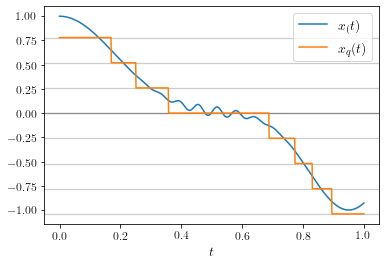

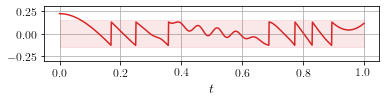

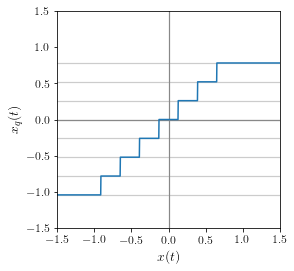

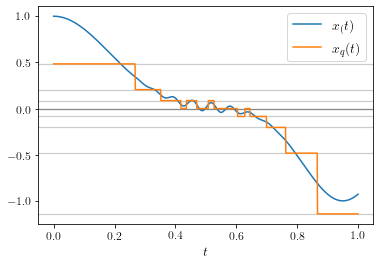

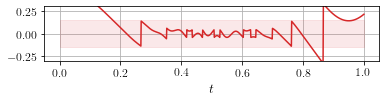

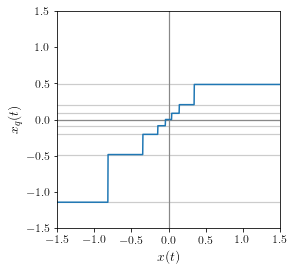

In [16]:
# Nombre de niveaux de quantification
K = 8
q = 0.3

# Quantification uniforme
levels_u = np.arange(-K/2,K/2) * q

# Quantification en loi A
A = 10
qA = 0.26
levels_u = np.arange(-K/2,K/2) * qA
alpha = np.abs(levels_u) * (1 + np.log(A))
levels_a = np.sign(levels_u) * np.where( alpha < 1, alpha/A, np.exp(alpha-1)/A )

# Signal temporel
N = 1000
n = np.linspace(0, 1, N)
# x = .8 * np.sin(2*np.pi*n**1.5) - n + .5
# x = (x-x.min()) / (x.max()-x.min()) * 2.1 - 1
x = np.exp(-n**2*15) - np.exp(-(n-.95)**2*30) + .05 * np.sin(n*100) * np.exp(-(n-.5)**2*50)

# Signal pour la caractéristique
ymin = -(K/2+1) * q
ymax =  (K/2+1) * q
y = np.linspace(ymin, ymax, N)

# Affichage
for levels, nom in [(levels_u,"U"), (levels_a,"A")]:
    
    # Signal temporel
    xq = quantif(x, levels)
    fig, ax = plt.subplots(figsize=(6,4))
    mygrid(ax, levels)
    ax.plot(n, x,  label="$x_(t)$")
    ax.plot(n, xq, label="$x_q(t)$")
    ax.set_xlabel("$t$")
    plt.legend()
    plt.savefig(f"quantification-signal-{nom}.svg", bbox_inches="tight")

    # Erreur
    fig, ax = plt.subplots(figsize=(6,1))
    ax.plot(n, x-xq, color="C3")
    ax.set_ylim(-.3, .3)
    ax.set_xlabel("$t$")
    ax.fill_between([0, 1], [-q/2, -q/2], [q/2, q/2],color='C3', alpha=0.1)
    plt.savefig(f"quantification-erreur-{nom}.svg", bbox_inches="tight")
    
    # Caractéristique
    yq = quantif(y, levels)
    fig, ax = plt.subplots(figsize=(4,4))
    mygrid(ax, levels, va=True)
    ax.plot(y, yq)
    ax.set_xlabel("$x(t)$")
    ax.set_ylabel("$x_q(t)$")
    ax.set_xlim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1.5, 1.6, .5))
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks(np.arange(-1.5, 1.6, .5))
    plt.savefig(f"TEST.svg", bbox_inches="tight")
    plt.savefig(f"quantification-caracteristique-{nom}.svg", bbox_inches="tight")

plt.show()